# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the censusData data set.
2. The label is income_binary, we are predicting whether an individual's salary is greater than 50k or less than or equal to 50k.
3. Just looking at the data plainly, I was think occupation, education, and education-num might be strong predictors of the label.
4. CDFI is a financial institution that provides low interest loans for underderserved communities. THe predictions from the model can be used by the CDFI to decide who qualifies for the low interest loans.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<AxesSubplot:xlabel='income_binary', ylabel='count'>

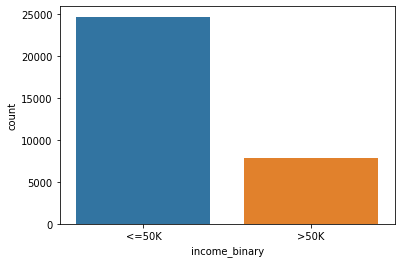

In [3]:
# YOUR CODE HERE
counts = df['income_binary'].value_counts()
counts

sns.countplot(x="income_binary", data=df)

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
# YOUR CODE HERE
df.shape

(32561, 15)

In [5]:
df.dtypes

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object

In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [7]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex_selfID,native-country,income_binary
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Non-Female,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [8]:
df.nunique()
#fnlwgt and capital-gain too much

age                  73
workclass             8
fnlwgt            21648
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex_selfID            2
capital-gain        106
capital-loss         92
hours-per-week       94
native-country       41
income_binary         2
dtype: int64

In [9]:
df.isnull().sum()

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

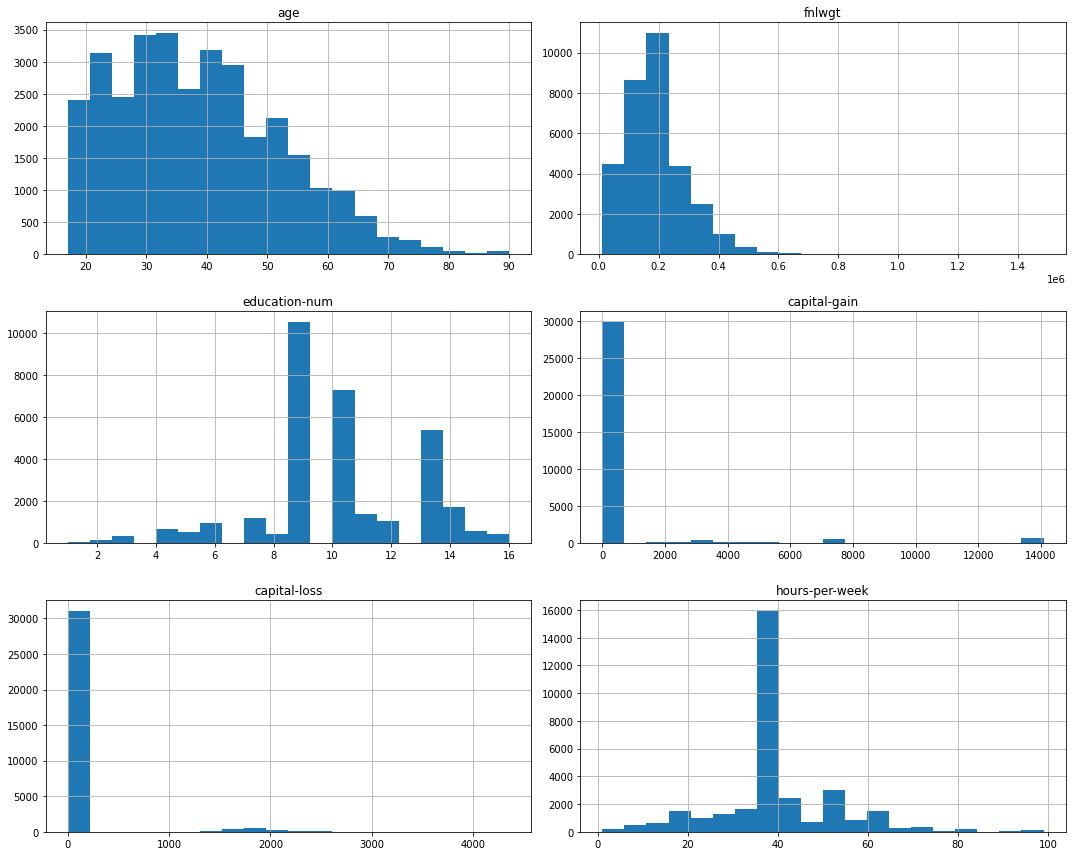

In [10]:
numeric = df.select_dtypes(include='number')
numeric.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()
#for numeric features, historgram, capital loss doesn t look useful

In [11]:
df['hours-per-week']

0        40.0
1        13.0
2        40.0
3        40.0
4        40.0
         ... 
32556    38.0
32557    40.0
32558    40.0
32559    20.0
32560    40.0
Name: hours-per-week, Length: 32561, dtype: float64

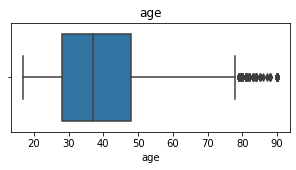

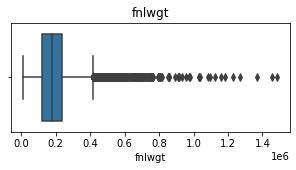

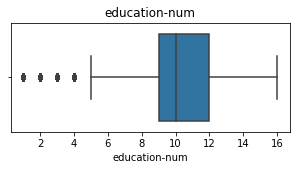

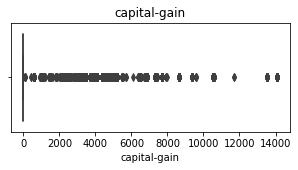

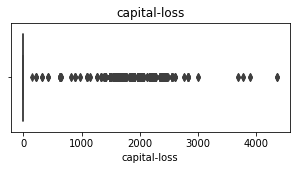

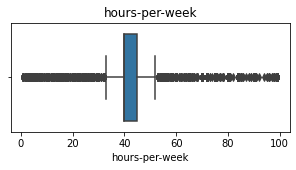

In [12]:
for col in numeric.columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

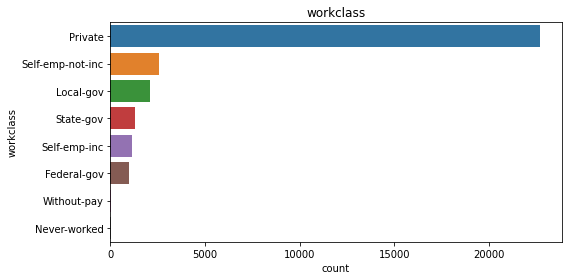

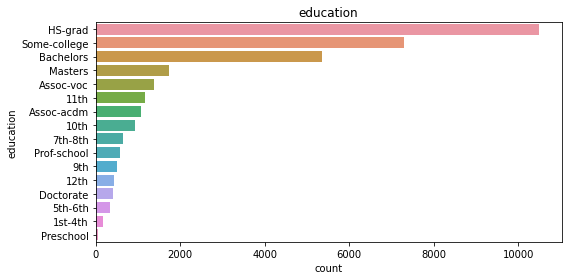

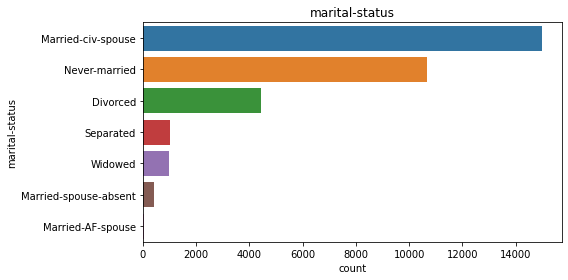

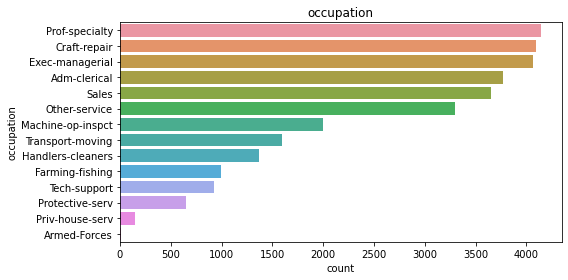

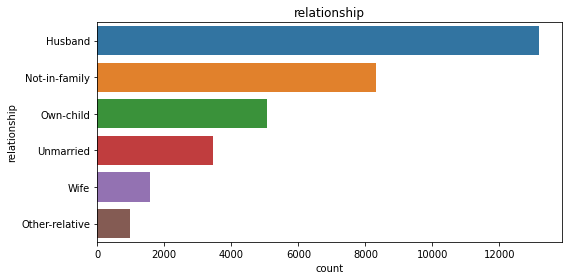

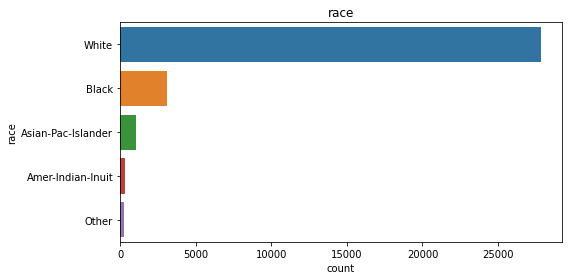

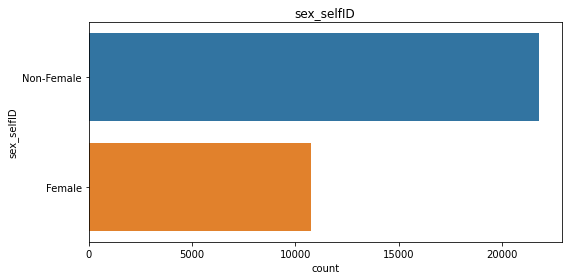

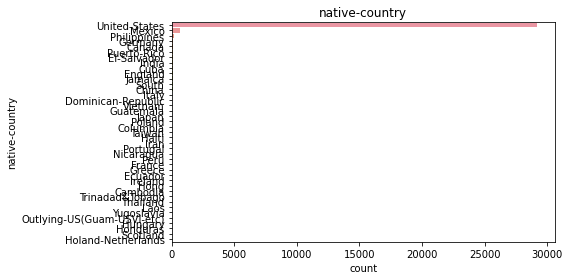

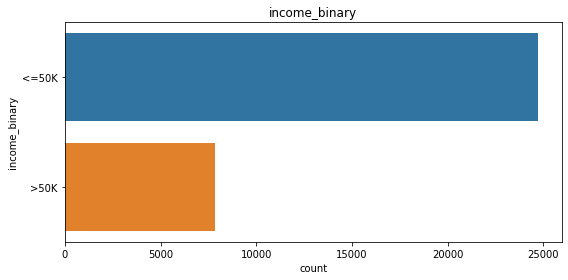

In [13]:
categorical = df.select_dtypes(include='object')
for col in categorical.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(col)
    plt.tight_layout()
    plt.show()

<AxesSubplot:xlabel='income_binary', ylabel='age'>

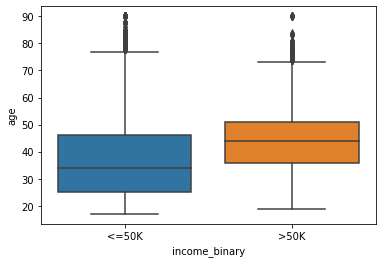

In [14]:
sns.boxplot(x='income_binary', y='age', data=df)

<AxesSubplot:xlabel='income_binary', ylabel='hours-per-week'>

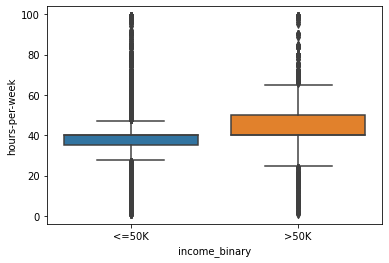

In [15]:
sns.boxplot(x='income_binary', y='hours-per-week', data=df)

<AxesSubplot:xlabel='income_binary', ylabel='education-num'>

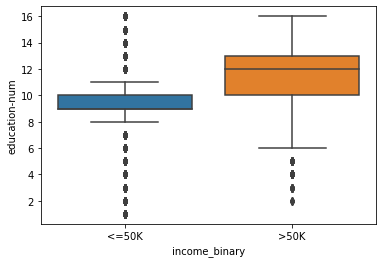

In [16]:
sns.boxplot(x='income_binary', y='education-num', data=df)

<AxesSubplot:xlabel='count', ylabel='sex_selfID'>

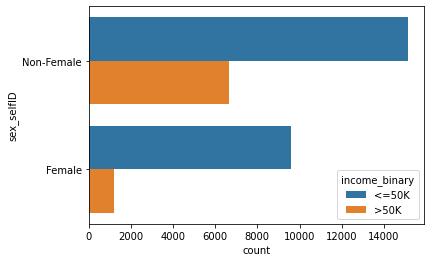

In [17]:
sns.countplot(y='sex_selfID', hue='income_binary', data=df)

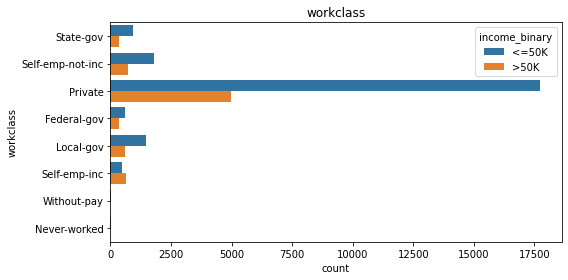

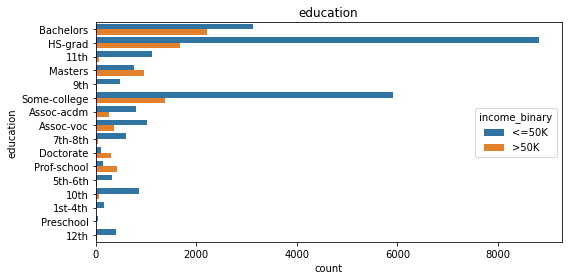

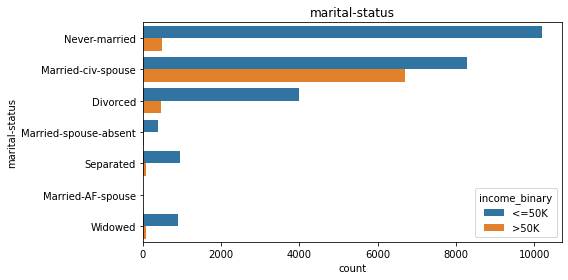

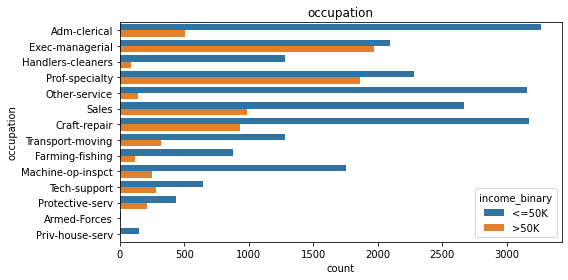

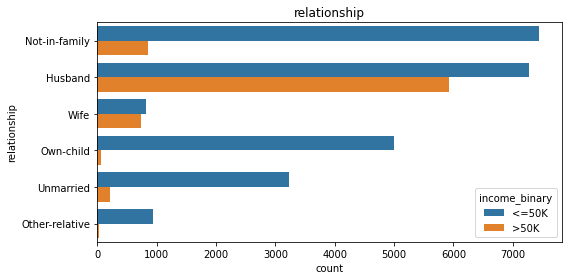

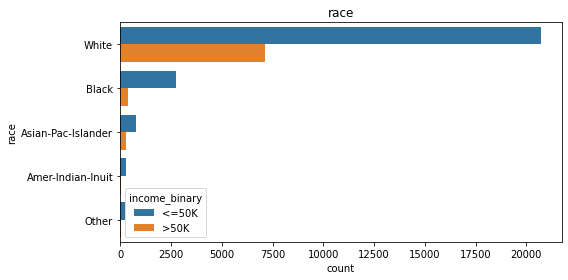

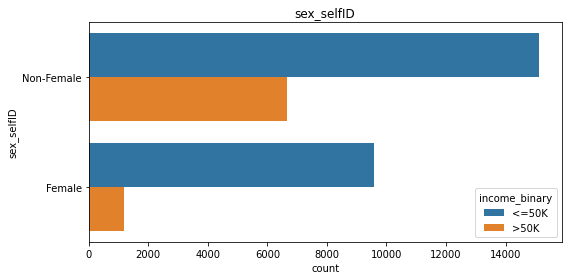

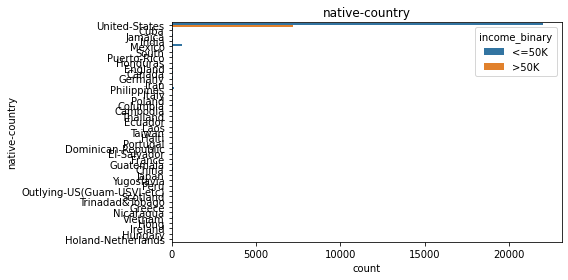

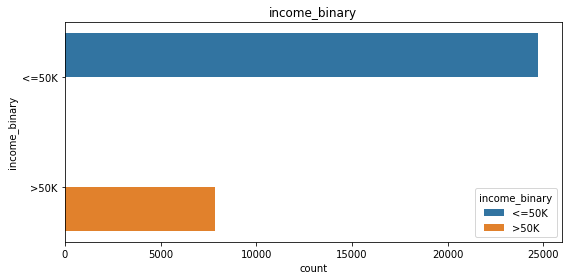

In [18]:
for col in categorical.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, hue='income_binary', data=df)
    plt.title(col)
    plt.tight_layout()
    plt.show()

<AxesSubplot:xlabel='income_binary', ylabel='capital-gain'>

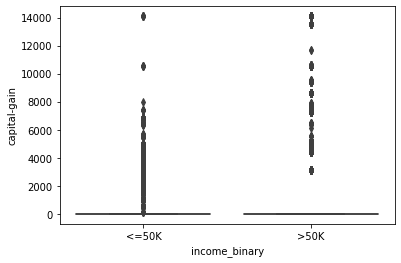

In [19]:
sns.boxplot(x='income_binary', y='capital-gain', data=df)

<AxesSubplot:>

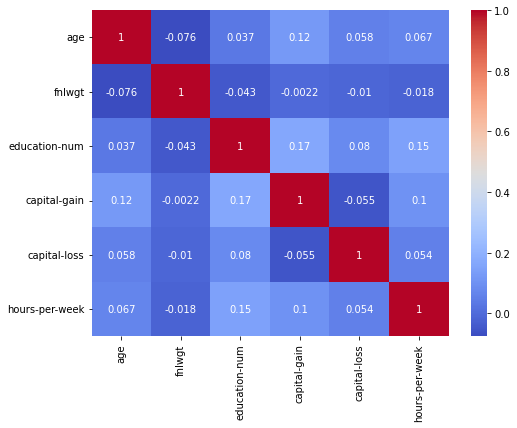

In [20]:
corr = numeric.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
#just with numeric features, for redundancy. not much redundancy

In [21]:
df['capital-loss'].dtype

dtype('int64')

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The label is actually imbalanced, with there being more data of individuals earning <=50k than >50k. Workclass and Occupation have the most amount of null values in the dataset, which is something we should consider. The features fnlwgt, capital-gain and capital-loss have a lot of unique values, but they are all numerical values (ints). They also have a lot of outliers, I might scale them.  It seems like education might be a promising predictor of income level, as more people earn more as the level of education increases (from the graph). Hours-per-week and age might also be a good predictor, according to the box plots. According to the count plots, sex and marital status might also be good predictors so I will one-hot transform them. I think I will remove education and use education-num since they are the same information in different formats.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. It seems like the dataset contains an overwhelmingly higher amount of data from people who identify as white than any other race. There is also an imbalance in that there are a lot more data from non-females than females. Yes there could be some features that serve as proxies such as occupation, native-country, workclass and more.
2. The people who are harmed are the people who are underrepresented in the set, such as non-white people and female identifying individuals. Because the model is trained on more of some groups, it could make less accurate predictions for the underrepresented communities. In our business case, this could harm individuals fianncially as they we are making important financial decisions for them.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [22]:
# YOUR CODE HERE
df_clean = df.copy()

In [23]:
for n_col in numeric.columns:
    df_clean[n_col].fillna(df_clean[n_col].median(), inplace=True)

In [24]:
categorical.columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex_selfID', 'native-country',
       'income_binary'],
      dtype='object')

In [25]:
categorical_features = [col for col in categorical.columns if col != "income_binary"]
for c_col in categorical_features:
    df_clean[c_col].fillna(df_clean[c_col].mode()[0], inplace=True)

In [26]:
df_clean.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64

In [27]:
df_clean.drop(columns='fnlwgt', inplace=True)

In [28]:
df_clean.drop(columns='education', inplace=True)

In [29]:
df_clean["income_binary"] = (df_clean["income_binary"].map({"<=50K": 0,">50K": 1}))

In [30]:
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()

categorical_cols

['workclass',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex_selfID',
 'native-country']

In [31]:
df_clean["native-country"] = df_clean["native-country"].where(
    df_clean["native-country"].isin(["United-States", "Mexico"]),
    "Other"
)

In [32]:
df_clean["native-country"].value_counts()

United-States    29753
Other             2165
Mexico             643
Name: native-country, dtype: int64

In [33]:
df_workclass = pd.get_dummies(df_clean['workclass'], prefix='workclass_')
df_workclass

,workclass__Federal-gov,workclass__Local-gov,workclass__Never-worked,workclass__Private,workclass__Self-emp-inc,workclass__Self-emp-not-inc,workclass__State-gov,workclass__Without-pay
0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0
2,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0
4,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
32556,0,0,0,1,0,0,0,0
32557,0,0,0,1,0,0,0,0
32558,0,0,0,1,0,0,0,0
32559,0,0,0,1,0,0,0,0


In [34]:
df_clean = df_clean.join(df_workclass)

In [35]:
df_clean.drop(columns = 'workclass', inplace=True)

In [36]:
df_clean.columns

Index(['age', 'education-num', 'marital-status', 'occupation', 'relationship',
       'race', 'sex_selfID', 'capital-gain', 'capital-loss', 'hours-per-week',
       'native-country', 'income_binary', 'workclass__Federal-gov',
       'workclass__Local-gov', 'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay'],
      dtype='object')

In [37]:
df_marital = pd.get_dummies(df_clean['marital-status'], prefix='marital-status_')
df_marital

,marital-status__Divorced,marital-status__Married-AF-spouse,marital-status__Married-civ-spouse,marital-status__Married-spouse-absent,marital-status__Never-married,marital-status__Separated,marital-status__Widowed
0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0
2,1,0,0,0,0,0,0
3,0,0,1,0,0,0,0
4,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...
32556,0,0,1,0,0,0,0
32557,0,0,1,0,0,0,0
32558,0,0,0,0,0,0,1
32559,0,0,0,0,1,0,0


In [38]:
df_clean = df_clean.join(df_marital)
df_clean.drop(columns = 'marital-status', inplace=True)
df_clean.columns

Index(['age', 'education-num', 'occupation', 'relationship', 'race',
       'sex_selfID', 'capital-gain', 'capital-loss', 'hours-per-week',
       'native-country', 'income_binary', 'workclass__Federal-gov',
       'workclass__Local-gov', 'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay',
       'marital-status__Divorced', 'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
       'marital-status__Widowed'],
      dtype='object')

In [39]:
df_occupation = pd.get_dummies(df_clean['occupation'], prefix='occupation_')
df_occupation

,occupation__Adm-clerical,occupation__Armed-Forces,occupation__Craft-repair,occupation__Exec-managerial,occupation__Farming-fishing,occupation__Handlers-cleaners,occupation__Machine-op-inspct,occupation__Other-service,occupation__Priv-house-serv,occupation__Prof-specialty,occupation__Protective-serv,occupation__Sales,occupation__Tech-support,occupation__Transport-moving
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0,0,0,0,0,0,0,0,0,0,0,0,1,0
32557,0,0,0,0,0,0,1,0,0,0,0,0,0,0
32558,1,0,0,0,0,0,0,0,0,0,0,0,0,0
32559,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [40]:
df_clean = df_clean.join(df_occupation)
df_clean.drop(columns = 'occupation', inplace=True)
df_clean.columns

Index(['age', 'education-num', 'relationship', 'race', 'sex_selfID',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income_binary', 'workclass__Federal-gov', 'workclass__Local-gov',
       'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay',
       'marital-status__Divorced', 'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
       'marital-status__Widowed', 'occupation__Adm-clerical',
       'occupation__Armed-Forces', 'occupation__Craft-repair',
       'occupation__Exec-managerial', 'occupation__Farming-fishing',
       'occupation__Handlers-cleaners', 'occupation__Machine-op-inspct',
       'occupation__Other-service', 'occupation__Priv-house-serv',
       'occupation__Prof-specialty',

In [41]:
df_relationship = pd.get_dummies(df_clean['relationship'], prefix='relationship_')
df_relationship

,relationship__Husband,relationship__Not-in-family,relationship__Other-relative,relationship__Own-child,relationship__Unmarried,relationship__Wife
0,0,1,0,0,0,0
1,1,0,0,0,0,0
2,0,1,0,0,0,0
3,1,0,0,0,0,0
4,0,0,0,0,0,1
...,...,...,...,...,...,...
32556,0,0,0,0,0,1
32557,1,0,0,0,0,0
32558,0,0,0,0,1,0
32559,0,0,0,1,0,0


In [42]:
df_clean = df_clean.join(df_relationship)
df_clean.drop(columns = 'relationship', inplace=True)
df_clean.columns

Index(['age', 'education-num', 'race', 'sex_selfID', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income_binary',
       'workclass__Federal-gov', 'workclass__Local-gov',
       'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay',
       'marital-status__Divorced', 'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
       'marital-status__Widowed', 'occupation__Adm-clerical',
       'occupation__Armed-Forces', 'occupation__Craft-repair',
       'occupation__Exec-managerial', 'occupation__Farming-fishing',
       'occupation__Handlers-cleaners', 'occupation__Machine-op-inspct',
       'occupation__Other-service', 'occupation__Priv-house-serv',
       'occupation__Prof-specialty', 'occupation__Pr

In [43]:
df_race = pd.get_dummies(df_clean['race'], prefix='race_')
df_race

,race__Amer-Indian-Inuit,race__Asian-Pac-Islander,race__Black,race__Other,race__White
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,1,0,0
4,0,0,1,0,0
...,...,...,...,...,...
32556,0,0,0,0,1
32557,0,0,0,0,1
32558,0,0,0,0,1
32559,0,0,0,0,1


In [44]:
df_clean = df_clean.join(df_race)
df_clean.drop(columns = 'race', inplace=True)
df_clean.columns

Index(['age', 'education-num', 'sex_selfID', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income_binary',
       'workclass__Federal-gov', 'workclass__Local-gov',
       'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay',
       'marital-status__Divorced', 'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
       'marital-status__Widowed', 'occupation__Adm-clerical',
       'occupation__Armed-Forces', 'occupation__Craft-repair',
       'occupation__Exec-managerial', 'occupation__Farming-fishing',
       'occupation__Handlers-cleaners', 'occupation__Machine-op-inspct',
       'occupation__Other-service', 'occupation__Priv-house-serv',
       'occupation__Prof-specialty', 'occupation__Protective

In [45]:
df_sex = pd.get_dummies(df_clean['sex_selfID'], prefix='sex_')
df_sex

,sex__Female,sex__Non-Female
0,0,1
1,0,1
2,0,1
3,0,1
4,1,0
...,...,...
32556,1,0
32557,0,1
32558,1,0
32559,0,1


In [46]:
df_clean = df_clean.join(df_sex)
df_clean.drop(columns = 'sex_selfID', inplace=True)
df_clean.columns

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income_binary',
       'workclass__Federal-gov', 'workclass__Local-gov',
       'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay',
       'marital-status__Divorced', 'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
       'marital-status__Widowed', 'occupation__Adm-clerical',
       'occupation__Armed-Forces', 'occupation__Craft-repair',
       'occupation__Exec-managerial', 'occupation__Farming-fishing',
       'occupation__Handlers-cleaners', 'occupation__Machine-op-inspct',
       'occupation__Other-service', 'occupation__Priv-house-serv',
       'occupation__Prof-specialty', 'occupation__Protective-serv',
      

In [47]:
df_native = pd.get_dummies(df_clean['native-country'], prefix='native_')
df_native

,native__Mexico,native__Other,native__United-States
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,1,0
...,...,...,...
32556,0,0,1
32557,0,0,1
32558,0,0,1
32559,0,0,1


In [48]:
df_clean = df_clean.join(df_native)
df_clean.drop(columns = 'native-country', inplace=True)
df_clean.columns

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income_binary', 'workclass__Federal-gov',
       'workclass__Local-gov', 'workclass__Never-worked', 'workclass__Private',
       'workclass__Self-emp-inc', 'workclass__Self-emp-not-inc',
       'workclass__State-gov', 'workclass__Without-pay',
       'marital-status__Divorced', 'marital-status__Married-AF-spouse',
       'marital-status__Married-civ-spouse',
       'marital-status__Married-spouse-absent',
       'marital-status__Never-married', 'marital-status__Separated',
       'marital-status__Widowed', 'occupation__Adm-clerical',
       'occupation__Armed-Forces', 'occupation__Craft-repair',
       'occupation__Exec-managerial', 'occupation__Farming-fishing',
       'occupation__Handlers-cleaners', 'occupation__Machine-op-inspct',
       'occupation__Other-service', 'occupation__Priv-house-serv',
       'occupation__Prof-specialty', 'occupation__Protective-serv',
       'occupation__Sales', 'oc

In [49]:
df_clean.dtypes

age                                      float64
education-num                              int64
capital-gain                               int64
capital-loss                               int64
hours-per-week                           float64
income_binary                              int64
workclass__Federal-gov                     uint8
workclass__Local-gov                       uint8
workclass__Never-worked                    uint8
workclass__Private                         uint8
workclass__Self-emp-inc                    uint8
workclass__Self-emp-not-inc                uint8
workclass__State-gov                       uint8
workclass__Without-pay                     uint8
marital-status__Divorced                   uint8
marital-status__Married-AF-spouse          uint8
marital-status__Married-civ-spouse         uint8
marital-status__Married-spouse-absent      uint8
marital-status__Never-married              uint8
marital-status__Separated                  uint8
marital-status__Wido

In [50]:
corr_matrix = round(df_clean.corr(),5)
corr_matrix

,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,workclass__Federal-gov,workclass__Local-gov,workclass__Never-worked,workclass__Private,...,race__Amer-Indian-Inuit,race__Asian-Pac-Islander,race__Black,race__Other,race__White,sex__Female,sex__Non-Female,native__Mexico,native__Other,native__United-States
age,1.00000,0.03670,0.12474,0.05754,0.06655,0.23312,0.05157,0.06088,-0.01940,-0.18891,...,-0.00974,-0.01194,-0.01905,-0.03418,0.03333,-0.08838,0.08838,-0.05501,0.01033,0.01810
education-num,0.03670,1.00000,0.16709,0.07992,0.14657,0.33515,0.06052,0.09794,-0.01512,-0.16804,...,-0.02934,0.06209,-0.07527,-0.04413,0.05135,-0.01228,0.01228,-0.21767,-0.01699,0.12296
capital-gain,0.12474,0.16709,1.00000,-0.05514,0.10098,0.34756,0.00805,0.00013,-0.00373,-0.06007,...,-0.00182,0.00091,-0.03014,-0.01194,0.02828,-0.07256,0.07256,-0.02609,-0.00796,0.02000
capital-loss,0.05754,0.07992,-0.05514,1.00000,0.05421,0.15053,0.01080,0.01467,-0.00318,-0.03789,...,-0.01295,0.00447,-0.02176,-0.00596,0.02104,-0.04557,0.04557,-0.02204,-0.00399,0.01446
hours-per-week,0.06655,0.14657,0.10098,0.05421,1.00000,0.22840,0.01334,0.01158,-0.00922,-0.11190,...,-0.00449,-0.00471,-0.05349,-0.00715,0.05007,-0.22824,0.22824,-0.00059,-0.00816,0.00753
income_binary,0.23312,0.33515,0.34756,0.15053,0.22840,1.00000,0.05937,0.03309,-0.00826,-0.12557,...,-0.02872,0.01054,-0.08909,-0.03183,0.08522,-0.21598,0.21598,-0.06290,-0.00875,0.03894
workclass__Federal-gov,0.05157,0.06052,0.00805,0.01080,0.01334,0.05937,1.00000,-0.04568,-0.00256,-0.30466,...,0.01835,0.01381,0.04740,-0.00198,-0.05100,-0.00099,0.00099,-0.02343,-0.00571,0.01668
workclass__Local-gov,0.06088,0.09794,0.00013,0.01467,0.01158,0.03309,-0.04568,1.00000,-0.00384,-0.45814,...,0.02061,-0.01980,0.03707,-0.01023,-0.02413,0.03797,-0.03797,-0.02100,-0.02320,0.03100
workclass__Never-worked,-0.01940,-0.01512,-0.00373,-0.00318,-0.00922,-0.00826,-0.00256,-0.00384,1.00000,-0.02563,...,-0.00144,-0.00266,0.00945,-0.00134,-0.00582,-0.00140,0.00140,-0.00208,-0.00391,0.00450
workclass__Private,-0.18891,-0.16804,-0.06007,-0.03789,-0.11190,-0.12557,-0.30466,-0.45814,-0.02563,1.00000,...,-0.01415,-0.00195,0.00855,0.02496,-0.00869,0.07208,-0.07208,0.05201,0.02398,-0.04706


In [51]:
corrs = corr_matrix['income_binary']
corrs

age                                      0.23312
education-num                            0.33515
capital-gain                             0.34756
capital-loss                             0.15053
hours-per-week                           0.22840
income_binary                            1.00000
workclass__Federal-gov                   0.05937
workclass__Local-gov                     0.03309
workclass__Never-worked                 -0.00826
workclass__Private                      -0.12557
workclass__Self-emp-inc                  0.13947
workclass__Self-emp-not-inc              0.03002
workclass__State-gov                     0.01484
workclass__Without-pay                  -0.01168
marital-status__Divorced                -0.12699
marital-status__Married-AF-spouse        0.01206
marital-status__Married-civ-spouse       0.44470
marital-status__Married-spouse-absent   -0.04253
marital-status__Never-married           -0.31844
marital-status__Separated               -0.07439
marital-status__Wido

In [52]:
corrs_sorted = corrs.sort_values(ascending=False)
corrs_sorted

income_binary                            1.00000
marital-status__Married-civ-spouse       0.44470
relationship__Husband                    0.40104
capital-gain                             0.34756
education-num                            0.33515
age                                      0.23312
hours-per-week                           0.22840
sex__Non-Female                          0.21598
occupation__Exec-managerial              0.21486
capital-loss                             0.15053
workclass__Self-emp-inc                  0.13947
relationship__Wife                       0.12326
occupation__Prof-specialty               0.11299
race__White                              0.08522
workclass__Federal-gov                   0.05937
native__United-States                    0.03894
workclass__Local-gov                     0.03309
workclass__Self-emp-not-inc              0.03002
occupation__Protective-serv              0.02812
occupation__Tech-support                 0.02570
occupation__Sales   

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I handled numeric missing values by replacing it with the median so that they wouldn't get affect by skewed data (which is what would happen if I replaced it with mean). I replaced missing data for categorical features with the mode, as it preserves the common category. I removed the features fnlwgt since it is not a meaningful characteristic and education since it is a redundant feature better expression by education-num. I grouped native-country into US, Mexico, and other countries because US took an overwhelming lead in data count, and one-hot encoding would be easier with 3 categories than 41. I applied one-hot encoding to all remain categorical features, except for income-binary which I mapped into numerical binary values. I did not winsorize or remove outliers since I thought extreme values in capital-loss or gain might be useful and valid observations. I am choosing DT as my model since it provides understable decision rules.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [53]:
# Create labeled examples from the dataset
# YOUR CODE HERE
y = df_clean['income_binary']
X = df_clean.drop(columns = 'income_binary', axis=1)

In [54]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

In [56]:
# Train, test and evaluate your model
# YOUR CODE HERE
model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 5, min_samples_leaf = 1)
model.fit(X_train, y_train)
class_label_predictions = model.predict(X_test)
acc = accuracy_score(y_test, class_label_predictions)
f1 = f1_score(y_test, class_label_predictions, average='binary')

print("Accuracy:", acc)
print("F1:", f1)

Accuracy: 0.8470703844736519
F1: 0.6122703207723451


In [57]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
param_grid = {'max_depth': [5, 8, 10, 12, 15, 20, 25, 30], 'min_samples_leaf': [1, 2, 5, 10, 15, 20, 30, 50]}
grid = GridSearchCV(model,param_grid,cv=5,scoring="f1")
grid_search = grid.fit(X_train, y_train)

print(grid_search.best_params_['max_depth'])
print(grid_search.best_params_['min_samples_leaf'])

10
20


In [58]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
model_best = DecisionTreeClassifier(criterion='entropy', max_depth = 10, min_samples_leaf = 20)
model_best.fit(X_train, y_train)
class_label_predictions_b = model_best.predict(X_test)
acc_score_b = accuracy_score(y_test, class_label_predictions_b)
f1_sc_b = f1_score(y_test, class_label_predictions_b, average='binary')

print("Accuracy:", acc_score_b)
print("F1:", f1_sc_b)

Accuracy: 0.8511239405478442
F1: 0.6768


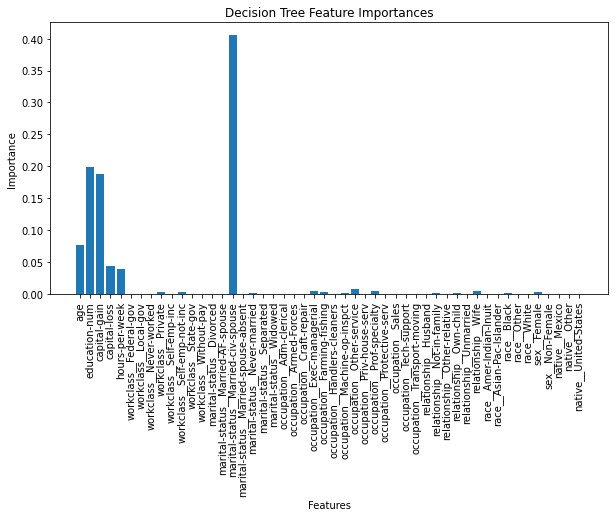

In [59]:
# Interpret your model's outputs 
# YOUR CODE HERE
importance = model_best.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X_train.columns, importance)

plt.title("Decision Tree Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=90)
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose Decision Trees because thought it would produce understandable decision rules and is more interpretable.
2. I learned that more complex models do not guarantee better performance. I expected higher optimal values for max_depth hyperparameter, however both max_depth and min_samples_leaf stopped at rather lower values from the GridSEarchCV optimization. 
3. According to the bar graph, apparently Marital status (for married civ spouse) was an important predictor in preidcting the income, followed by education-num as well as capital-gain. It is interesting how marital status was only a strong predictor for married civ spouses, and very insignifcant for people of other marital status. 
4. I did use race and gender as features when training the model. The data also does contain more female and white individuals, so one might consider removing the feature as it may inflict bias. Women and racial minorities could get harmed by this underrepresentation. This could lead to false negatives which could cause lack of opportunies for deserving candidates.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [60]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [61]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
input_layer = keras.layers.InputLayer(input_shape=(n_features,), name='input')
nn_model.add(input_layer)

# I chose 2 hidden layers with 32 and 16 neurons respectively. I used ReLU as activation functions 
# it is effective for non linear relationships.
# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# YOUR CODE HERE
hidden_layer_1 = keras.layers.Dense(units=32, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=16, activation='relu', name='hl_2')
nn_model.add(hidden_layer_2)

#I used sigmoid as the activation function since this is a binary classification problem.
# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output') 
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hl_1 (Dense)                 (None, 32)                1632      
_________________________________________________________________
hl_2 (Dense)                 (None, 16)                528       
_________________________________________________________________
output (Dense)               (None, 1)                 17        
Total params: 2,177
Trainable params: 2,177
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [63]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)
# I chose 0.01 because it is small enough to avoid passing over the minimum but large enouch to
# to finish in a decent amount of epochs.

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [64]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [65]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [66]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [67]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0, # disable the default progress bar,
    validation_split=0.2,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)],
) 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

#I think 100 epochs is good because it gives the neural network enough time to learn the 
# patterns while reducing overfitting.

Epoch [10/ 100], Loss: 0.3144, Accuracy: 0.8543, Val_loss: 0.3170, Val_accuracy: 0.8532
Epoch [20/ 100], Loss: 0.3071, Accuracy: 0.8577, Val_loss: 0.3133, Val_accuracy: 0.8559
Epoch [30/ 100], Loss: 0.3025, Accuracy: 0.8593, Val_loss: 0.3110, Val_accuracy: 0.8573
Epoch [40/ 100], Loss: 0.2984, Accuracy: 0.8612, Val_loss: 0.3105, Val_accuracy: 0.8587
Epoch [50/ 100], Loss: 0.2951, Accuracy: 0.8629, Val_loss: 0.3104, Val_accuracy: 0.8579
Epoch [60/ 100], Loss: 0.2922, Accuracy: 0.8640, Val_loss: 0.3086, Val_accuracy: 0.8608
Epoch [70/ 100], Loss: 0.2900, Accuracy: 0.8652, Val_loss: 0.3091, Val_accuracy: 0.8595
Epoch [80/ 100], Loss: 0.2876, Accuracy: 0.8660, Val_loss: 0.3090, Val_accuracy: 0.8612
Epoch [90/ 100], Loss: 0.2860, Accuracy: 0.8667, Val_loss: 0.3107, Val_accuracy: 0.8595
Epoch [100/ 100], Loss: 0.2840, Accuracy: 0.8676, Val_loss: 0.3111, Val_accuracy: 0.8606
Elapsed time: 114.53s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



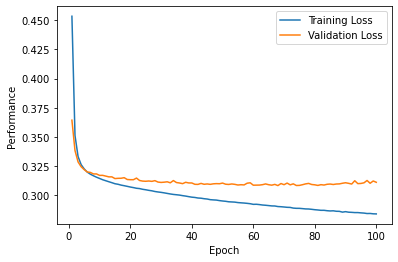

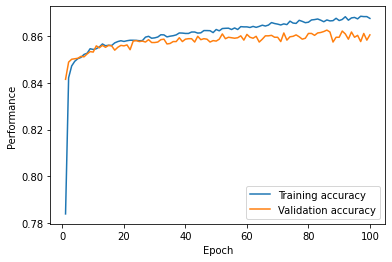

In [69]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation accuracy')

plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()


### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [71]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE
probability_predictions = nn_model.predict(X_test_scaled)
class_predictions = []
for i in range(len(probability_predictions)):
    if probability_predictions[i] >= 0.5:
        class_pred = 1
    else:
        class_pred = 0
    class_predictions.append(class_pred)

In [76]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE
nn_accuracy = accuracy_score(y_test, class_predictions)
nn_f1 = f1_score(y_test, class_predictions)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.8548089915243827
Neural Network F1 Score: 0.682769726247987


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I chose 2 hidden layers, 32 and 16 unites which has enough complexity for learning patterns without making the model too complex to avoid overfitting. I chose ReLU as activation function for the hidden layers and sigmoid as the function for the output layer to effectively learn nonlinear relationships and the sigmoid is to map probabilities from 0 to 1. Finally I chose 0.01 as the activation rate since it is low enough to allow gradual learning and 100 as my number of epochs so that the model would have enough time to learn.
2. The training loss initially took a deep dive and started gradually decreasing, while the training accuracy took a sharp increase in the first few epochs and stayed pretty much stable. I think we do in fact see some mild overfitting, but not too severe. Both the Validation Loss and Validation Accuracy stay constant on average rather than going in the undesirable direction. However, if I contintue to train with more epochs I might risk overfitting since we already see an increasing difference between the validation and training scores (which is not something we want to see too much).
3. The test accuracy score was about 0.8548 and F1 score was 0.6827. This was pretty close to the performance of the DecisionTree model that I implemented, so I was not super surprised. But I did expect a little more improvement from the neural network. 

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [78]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree Model': [acc_score_b, f1_sc_b],
    'Neural Network': [nn_accuracy, nn_f1]
 })
print(results.to_string(index=False))

   Metric  Decision Tree Model  Neural Network
 Accuracy             0.851124        0.854809
 F1 Score             0.676800        0.682770


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Both models actually performed very similar to each other. The neural network performed very slightly better than the Decision Tree Model (with a difference of about 0.01 for both). 
2. I do not think the added complexity was worth it because the improvement in the accuracy and f1 scores was very minute. Neural networks require more effort in terms of hyperparameter tuning and training, and I do not think that it is justified for a minimal performance increase.
3. I would recommend the Decision Tree since it acheived accuracy close to neural networks while being more interpretable, making it easier to explain to clients the logic behind some decisions and feature selection. It also takes less time to train.
4. Because the F1 scores are not the best they can be, I would try to address the class imbalance issue by applying more penalty to incorrect minority predictions or selecting the training set more equally. I would also try and experiment with more hyperparameters and other models to see if I can improve the scores. In addition, I would try to evaluate using L2 regularization to see if I can spot and avoid overfitting.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. In this project, AI was extremely helpful in helping me create clean code that helps me visualize. I produced lots of charts and graphs and I used AI to get help with syntax to make the graphs easy to read (scaled, mapped properly, etc). Because this was very syntax based, AI served as the perfect assistant to accelerate my work speed so that I can focus more on feature engineering and models. 
2. I think feature engineering took the majority of the time for me, because there was a lot of data and features that I had to look at both individually and in relation with other features. There was a lot of redundant code, like replacing null values, in which I would simply copy paste and change values. Like mentioned previously, I used AI to create clean plots. A few times I also fed AI the plots that I produced to address an issue and get ideas of what I can do with that data. For example, remove a feature that simply has too many null values, or combine education-num and education.
3. There were some decisions that I talked through with AI to understand the benefits and trade-offs of certain decisions, so I could make more educatioed ones. There are plenty of ways to do this capstone, and I would try different feature engineering methods next time.
4. I would want to put more emphasize in addressing class imbalance since that seems like an important issue. For this scenario, it is more detrimental to get incorrect predictions for minorities (<50k and false negatives for that group). 